# MgO Defect Thermodynamics from Scratch

## Module 2 — Bulk Convergence and Relaxation

### Research Question

Which ENCUT and k-point mesh provide converged energies for MgO?

### Physics

The plane-wave basis and k-point mesh control the numerical accuracy of a VASP calculation.

The energy should become stable as ENCUT and k-point density increase.

### Goals

1. Prepare the bulk VASP input information.
2. Parse ENCUT convergence results.
3. Select a converged ENCUT.
4. Parse k-point convergence results.
5. Select a converged k-point mesh.
6. Inspect the relaxed bulk result.
7. Obtain the relaxed primitive structure.

## Exercise 2.1 — Prepare the Bulk VASP Inputs

## Exercise 2.2 — Parse the ENCUT Convergence Results

## Exercise 2.3 — Select a Converged ENCUT

### K-point Convergence — Same General Procedure

## Exercise 2.4 — Inspect the Relaxed Bulk Result

## Exercise 2.5 — Extract the Relaxed Primitive Structure

## Exercise 2.1 — Prepare the VASP Input Information

### Purpose

- Convert the primitive structure into a POSCAR object.
- Read the default doped POTCAR mapping.
- Identify the POTCAR symbol for each element.
- Prepare for the convergence calculations.

In [6]:
from pymatgen.io.vasp.inputs import Potcar, Kpoints, Incar, Poscar, VaspInput
from monty.serialization import loadfn
from pathlib import Path
from pymatgen.core import Structure
import doped

In [9]:
# Load the data of primitive structure
project_root = Path.cwd().parent
prim_struc_path = (project_root/ "MgO"/ "Input_files"/ "prim_struc_POSCAR")

print("Structure path:",prim_struc_path)
print("Structure exists:", prim_struc_path.exists())

prim_struc = Structure.from_file(prim_struc_path) #Structure is used to create an object from the information from the POSCAR file. 
#It reads the file and constructs a Structure object that represents the crystal structure described in the file.


Structure path: /Users/yu/Desktop/defect_dynamic/MgO/Input_files/prim_struc_POSCAR
Structure exists: True


In [ ]:
#POSCAR objection
poscar = Poscar(prim_struc)
print(type(poscar))
print(poscar)

In [ ]:
# Check the path of POTCAR files
doped_directory = Path(doped.__file__).parent  #POTCAR files are located in the doped package directory

potcar_yaml = (
    doped_directory
    / "VASP_sets"
    / "PotcarSet.yaml"
)

print("POTCAR configuration:", potcar_yaml)
print("File exists:", potcar_yaml.exists())

In [16]:
# Load YAML
potcar_dict = loadfn(potcar_yaml)

print("POTCAR dictionary keys:", potcar_dict.keys())
print("POTCAR dictionary content:", potcar_dict["POTCAR"])

potcar_dict.items()

POTCAR dictionary keys: dict_keys(['POTCAR_FUNCTIONAL', 'POTCAR'])
POTCAR dictionary content: {'Ac': 'Ac', 'Ag': 'Ag', 'Al': 'Al', 'Ar': 'Ar', 'As': 'As', 'At': 'At_d', 'Au': 'Au', 'B': 'B', 'Ba': 'Ba_sv', 'Be': 'Be', 'Bi': 'Bi_d', 'Br': 'Br', 'C': 'C', 'Ca': 'Ca_sv', 'Cd': 'Cd', 'Ce': 'Ce', 'Cl': 'Cl', 'Co': 'Co', 'Cr': 'Cr_pv', 'Cs': 'Cs_sv', 'Cu': 'Cu', 'Dy': 'Dy_3', 'Er': 'Er_3', 'Eu': 'Eu', 'F': 'F', 'Fe': 'Fe', 'Ga': 'Ga_d', 'Gd': 'Gd', 'Ge': 'Ge_d', 'H': 'H', 'He': 'He', 'Hf': 'Hf_pv', 'Hg': 'Hg', 'Ho': 'Ho_3', 'I': 'I', 'In': 'In_d', 'Ir': 'Ir', 'K': 'K_sv', 'Kr': 'Kr', 'La': 'La', 'Li': 'Li_sv', 'Lu': 'Lu_3', 'Mg': 'Mg', 'Mn': 'Mn_pv', 'Mo': 'Mo_sv', 'N': 'N', 'Na': 'Na_pv', 'Nb': 'Nb_sv', 'Nd': 'Nd_3', 'Ne': 'Ne', 'Ni': 'Ni', 'Np': 'Np', 'O': 'O', 'Os': 'Os', 'P': 'P', 'Pa': 'Pa', 'Pb': 'Pb_d', 'Pd': 'Pd', 'Pm': 'Pm_3', 'Pr': 'Pr_3', 'Pt': 'Pt', 'Pu': 'Pu', 'Rb': 'Rb_sv', 'Re': 'Re', 'Rh': 'Rh_pv', 'Ru': 'Ru_pv', 'S': 'S', 'Sb': 'Sb', 'Sc': 'Sc_sv', 'Se': 'Se', 'Si': 'Si', 'S

dict_items([('POTCAR_FUNCTIONAL', 'PBE'), ('POTCAR', {'Ac': 'Ac', 'Ag': 'Ag', 'Al': 'Al', 'Ar': 'Ar', 'As': 'As', 'At': 'At_d', 'Au': 'Au', 'B': 'B', 'Ba': 'Ba_sv', 'Be': 'Be', 'Bi': 'Bi_d', 'Br': 'Br', 'C': 'C', 'Ca': 'Ca_sv', 'Cd': 'Cd', 'Ce': 'Ce', 'Cl': 'Cl', 'Co': 'Co', 'Cr': 'Cr_pv', 'Cs': 'Cs_sv', 'Cu': 'Cu', 'Dy': 'Dy_3', 'Er': 'Er_3', 'Eu': 'Eu', 'F': 'F', 'Fe': 'Fe', 'Ga': 'Ga_d', 'Gd': 'Gd', 'Ge': 'Ge_d', 'H': 'H', 'He': 'He', 'Hf': 'Hf_pv', 'Hg': 'Hg', 'Ho': 'Ho_3', 'I': 'I', 'In': 'In_d', 'Ir': 'Ir', 'K': 'K_sv', 'Kr': 'Kr', 'La': 'La', 'Li': 'Li_sv', 'Lu': 'Lu_3', 'Mg': 'Mg', 'Mn': 'Mn_pv', 'Mo': 'Mo_sv', 'N': 'N', 'Na': 'Na_pv', 'Nb': 'Nb_sv', 'Nd': 'Nd_3', 'Ne': 'Ne', 'Ni': 'Ni', 'Np': 'Np', 'O': 'O', 'Os': 'Os', 'P': 'P', 'Pa': 'Pa', 'Pb': 'Pb_d', 'Pd': 'Pd', 'Pm': 'Pm_3', 'Pr': 'Pr_3', 'Pt': 'Pt', 'Pu': 'Pu', 'Rb': 'Rb_sv', 'Re': 'Re', 'Rh': 'Rh_pv', 'Ru': 'Ru_pv', 'S': 'S', 'Sb': 'Sb', 'Sc': 'Sc_sv', 'Se': 'Se', 'Si': 'Si', 'Sm': 'Sm_3', 'Sn': 'Sn_d', 'Sr': 'Sr_sv', 

In [ ]:
## Check default values of POTCAR symbols
#Use the element information of POSCAR to check the potcar symbol
potcar_names = []
for el in prim_struc.elements:
    element_name = str(el)
    potcar_name = potcar_dict["POTCAR"][element_name]
    print(f"Element{element_name}:{potcar_name}"  
    )
    potcar_names.append(potcar_name)
print(potcar_names)

ElementMg:Mg
ElementO:O
['Mg', 'O']


## Exercise 2.2 — Parse the ENCUT Convergence Results

### Purpose

- Locate the synthetic ENCUT calculations.
- Read multiple OUTCAR-like files.
- Extract ENCUT and final TOTEN.
- Calculate energy per atom.
- Build a structured convergence dataset.

In [18]:
from pathlib import Path
import pandas as pd

In [ ]:
#Check the OUTCAR file
project_root = Path.cwd().parent
data_root = (
    project_root
    /"data"
    /"raw"
    /"mgo_defect_thermodynamics_dataset"
)
convergence_root = (data_root /"01_bulk_convergence")

# test whether exist
print("convergence_dictionary:",convergence_root)
print("Dictionary exist:", convergence_root.exists())

#Check convergence file from the known dictionary Path.iterdir()
for item in sorted(convergence_root.iterdir()):
    print(item.name)

#rglob()
all_outcar_paths = list(
    convergence_root.rglob("OUTCAR")
)

print("Number of OUTCAR files:", len(all_outcar_paths))

for path in sorted(all_outcar_paths):
    print(path.relative_to(convergence_root))

convergence_dictionary: /Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence
Dictionary exist: True
encut
kpoints
Number of OUTCAR files: 13
encut/ENCUT_350/OUTCAR
encut/ENCUT_400/OUTCAR
encut/ENCUT_450/OUTCAR
encut/ENCUT_500/OUTCAR
encut/ENCUT_550/OUTCAR
encut/ENCUT_600/OUTCAR
encut/ENCUT_650/OUTCAR
kpoints/KPOINTS_2x2x2/OUTCAR
kpoints/KPOINTS_3x3x3/OUTCAR
kpoints/KPOINTS_4x4x4/OUTCAR
kpoints/KPOINTS_5x5x5/OUTCAR
kpoints/KPOINTS_6x6x6/OUTCAR
kpoints/KPOINTS_8x8x8/OUTCAR


In [27]:
# Filtering of OUTCAR of ENCUT
encut_outcar_paths = []
for path in all_outcar_paths:
    path_text = str(path).lower()
    if "encut" in path_text:
        encut_outcar_paths.append(path)

print("ENCUT OUTCAR files:",encut_outcar_paths)

print("All OUTCAR files:", len(all_outcar_paths))
print("ENCUT OUTCAR files:", len(encut_outcar_paths))


ENCUT OUTCAR files: [PosixPath('/Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence/encut/ENCUT_650/OUTCAR'), PosixPath('/Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence/encut/ENCUT_400/OUTCAR'), PosixPath('/Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence/encut/ENCUT_550/OUTCAR'), PosixPath('/Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence/encut/ENCUT_600/OUTCAR'), PosixPath('/Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence/encut/ENCUT_450/OUTCAR'), PosixPath('/Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence/encut/ENCUT_350/OUTCAR'), PosixPath('/Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence/encut/ENCUT_500/OUTCAR')]
All OUTCAR files: 13
ENCUT OUTCAR files: 7


In [29]:
#
sample_outcar = sorted(encut_outcar_paths)[0]

text = sample_outcar.read_text(encoding="utf-8")
lines = text.splitlines()

print("Sample file:", sample_outcar)
print("Number of lines:", len(lines))

for line in lines:
    if "ENCUT" in line:
        print(line)

for line in lines:
    if "TOTEN" in line:
        print(line)

Sample file: /Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence/encut/ENCUT_350/OUTCAR
Number of lines: 45
  ENCUT = 350
  free  energy   TOTEN  = -102.31851400 eV


In [39]:
from pathlib import Path

def parse_encut_outcar(
    outcar_path: Path,
    number_of_atoms: int,
) -> dict:
    """Parse ENCUT and final TOTEN from one OUTCAR-like file."""

    text = outcar_path.read_text(encoding="utf-8")
    lines = text.splitlines()

    encut_value = None
    toten_values = []

    for line in lines:
        if "ENCUT" in line:
            right_side = line.split("=", 1)[1]
            encut_value = float(right_side.split()[0])

        if "TOTEN" in line:
            right_side = line.split("=", 1)[1]
            total_energy = float(right_side.split()[0])
            toten_values.append(total_energy)

    final_toten = toten_values[-1]
    energy_per_atom = final_toten / number_of_atoms

    converged = "reached required accuracy" in text.lower()

    return {
        "encut_eV": encut_value,
        "total_energy_eV": final_toten,
        "energy_per_atom_eV": energy_per_atom,
        "converged": converged,
        "outcar_path": outcar_path,
    }

In [40]:
encut_values = None
toten_values = []

for line in lines:
    if "ENCUT" in line:
        right_side = line.split("=", 1)[1] #split from "=", and get the right side
        encut_value = float(right_side.split()[0]) #split from blank space

    if "TOTEN" in line:
        right_side = line.split("=", 1)[1]
        total_energy = float(right_side.split()[0])
        toten_values.append(total_energy)

final_toten = toten_values[-1]

number_of_atoms = prim_struc.num_sites
energy_per_atom = final_toten / number_of_atoms

converged = "reached required accuracy" in text.lower()

result = {
    "encut_eV": encut_value,
    "total_energy_eV": final_toten,
    "energy_per_atom_eV": energy_per_atom,
    "converged": converged,
    "outcar_path": sample_outcar,
}

print(result)



{'encut_eV': 350.0, 'total_energy_eV': -102.318514, 'energy_per_atom_eV': -51.159257, 'converged': True, 'outcar_path': PosixPath('/Users/yu/Desktop/defect_dynamic/data/raw/mgo_defect_thermodynamics_dataset/01_bulk_convergence/encut/ENCUT_350/OUTCAR')}


In [41]:
encut_records = []

for outcar_path in encut_outcar_paths:
    result = parse_encut_outcar(
        outcar_path=outcar_path,
        number_of_atoms=prim_struc.num_sites,
    )

    encut_records.append(result)

import pandas as pd

encut_df = pd.DataFrame(encut_records)

encut_df = (
    encut_df
    .sort_values("encut_eV")
    .reset_index(drop=True)
)

display(
    encut_df[
        [
            "encut_eV",
            "energy_per_atom_eV",
            "converged",
        ]
    ]
)

,encut_eV,energy_per_atom_eV,converged
0,350.0,-51.159257,True
1,400.0,-51.183407,True
2,450.0,-51.196007,True
3,500.0,-51.199507,True
4,550.0,-51.200507,True
5,600.0,-51.200707,True
6,650.0,-51.200757,True


## Exercise 2.3 — Select a Converged ENCUT

### Physics

ENCUT controls the size of the plane-wave basis set.

A larger ENCUT generally improves numerical accuracy but increases computational cost. The goal is therefore to find the lowest ENCUT that gives a sufficiently stable energy.

A tolerance of 5 meV/atom is used here, following the qualitative MgO workflow. A stricter calculation may use 1 meV/atom.

### Python

- Sort the results by ENCUT.
- Select the highest-ENCUT energy as the reference.
- Calculate the absolute energy difference in meV/atom.
- Filter the converged calculations.
- Plot the convergence curve.

In [42]:
# sort and choose reference energy
encut_df = (
    encut_df
    .sort_values("encut_eV")
    .reset_index(drop=True)
)

reference_energy = encut_df["energy_per_atom_eV"].iloc[-1]

In [44]:
# Calculate energy difference
encut_df["delta_meV_per_atom"] = (
    abs(
        encut_df["energy_per_atom_eV"]
        - reference_energy
    )
    * 1000
)

display(
    encut_df[
        [
            "encut_eV",
            "energy_per_atom_eV",
            "delta_meV_per_atom",
        ]
    ]
)

,encut_eV,energy_per_atom_eV,delta_meV_per_atom
0,350.0,-51.159257,41.50
1,400.0,-51.183407,17.35
2,450.0,-51.196007,4.75
3,500.0,-51.199507,1.25
4,550.0,-51.200507,0.25
5,600.0,-51.200707,0.05
6,650.0,-51.200757,0.00


In [ ]:
# Choose the convergence value
threshold = 5.0

converged_rows = encut_df[encut_df["delta_meV_per_atom"] <= 5]

selected_encut = converged_rows.iloc[0]["encut_eV"]

print("Selected ENCUT:", selected_encut, "eV")



Selected ENCUT: 450.0 eV


##
df["column"]          # 选择一列
df[condition]         # 根据条件筛选行
df.iloc[0]            # 按位置选择第一行
df["column"].iloc[0]  # 某一列的第一个值

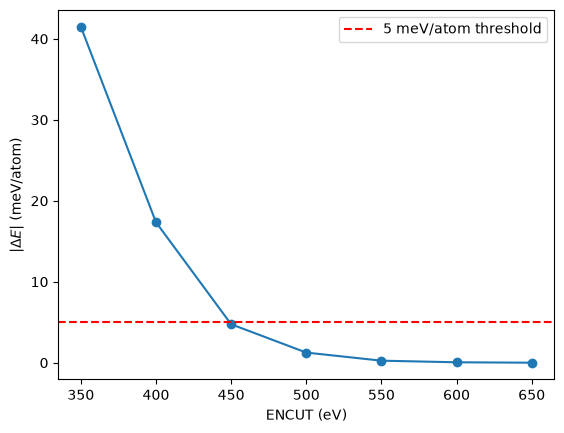

In [46]:
# Plot
import matplotlib.pyplot as plt

plt.plot(
    encut_df["encut_eV"],
    encut_df["delta_meV_per_atom"],
    marker="o",
)

plt.axhline(
    threshold,
    color="red",
    linestyle="--",
    label="5 meV/atom threshold",
)

plt.xlabel("ENCUT (eV)")
plt.ylabel(r"$|\Delta E|$ (meV/atom)")
plt.legend()
plt.show()

### K-point Convergence

K-point convergence follows the same general procedure as ENCUT convergence:

1. Run bulk calculations using increasingly dense k-point meshes.
2. Extract the final energy per atom.
3. Compare each energy with the densest mesh.
4. Select the lowest-cost mesh within the chosen energy tolerance.

Because the Python workflow is equivalent to the ENCUT analysis, it is not repeated here.

In [47]:
from pymatgen.core import Structure

convergence_poscar = Structure.from_file(
    sample_outcar.with_name("POSCAR")
)

print("Convergence cell sites:", convergence_poscar.num_sites)
print("Primitive cell sites:", prim_struc.num_sites)

Convergence cell sites: 8
Primitive cell sites: 2


In [50]:
# locate file
bulk_relax_directory = data_root / "02_bulk_relaxed"

initial_poscar_path = bulk_relax_directory / "POSCAR"
relaxed_contcar_path = bulk_relax_directory / "CONTCAR"
relaxed_outcar_path = bulk_relax_directory / "OUTCAR"

print("POSCAR:", initial_poscar_path.exists())
print("CONTCAR:", relaxed_contcar_path.exists())
print("OUTCAR:", relaxed_outcar_path.exists())

POSCAR: True
CONTCAR: True
OUTCAR: True


In [53]:
# Structure
bulk_before_relaxation = Structure.from_file(
    initial_poscar_path
)

bulk_after_relaxation = Structure.from_file(
    relaxed_contcar_path
)

print("Before:", bulk_before_relaxation.composition)
print("After:", bulk_after_relaxation.composition)

print("Number of sites:", bulk_after_relaxation.num_sites)

print("Volume before:", bulk_before_relaxation.volume)
print("Volume after:", bulk_after_relaxation.volume)

print("Lattice before:", bulk_before_relaxation.lattice.abc)
print("Lattice after:", bulk_after_relaxation.lattice.abc)

volume_change_percent = (
    (
        bulk_after_relaxation.volume
        - bulk_before_relaxation.volume
    )
    / bulk_before_relaxation.volume
    * 100
)

print("Volume change:", volume_change_percent, "%")

Before: Mg32 O32
After: Mg32 O32
Number of sites: 64
Volume before: 597.7988490239999
Volume after: 597.7988490239999
Lattice before: (8.424, 8.424, 8.424)
Lattice after: (8.424, 8.424, 8.424)
Volume change: 0.0 %


In [ ]:
outcar_text = relaxed_outcar_path.read_text(encoding="utf-8")

relaxation_converged = ("reached required accuracy"in outcar_text.lower())

print("Relaxation converged:", relaxation_converged)

Relaxation converged: True


## Exercise 2.5 — Extract the Relaxed Primitive Structure

### Workflow

The relaxed `CONTCAR` may contain a conventional cell or supercell.

Following the doped workflow, the relaxed structure is reduced to a clean primitive structure before defect generation.

### Physics

Primitive and supercell representations describe the same periodic crystal.

Using a primitive host allows `doped` to identify symmetry-equivalent sites and generate an appropriate defect supercell efficiently.

### Python

- Pass the relaxed structure to `get_primitive_structure()`.
- Inspect the reduced structure.
- Save it for the defect-generation module.

In [56]:
from doped.utils.symmetry import get_primitive_structure

In [57]:
relaxed_prim_struc = get_primitive_structure(bulk_after_relaxation)

print("Relaxed cell:", bulk_after_relaxation.composition)
print("Relaxed cell sites:", bulk_after_relaxation.num_sites)

print()

print("Primitive cell:", relaxed_prim_struc.composition)
print("Primitive cell sites:", relaxed_prim_struc.num_sites)
print("Primitive lattice:", relaxed_prim_struc.lattice)

Relaxed cell: Mg32 O32
Relaxed cell sites: 64

Primitive cell: Mg1 O1
Primitive cell sites: 2
Primitive lattice: 0.000000 2.106000 2.106000
2.106000 0.000000 2.106000
2.106000 2.106000 0.000000


In [59]:
#Save
relaxed_output_directory = (
    project_root
    / "MgO"
    / "Bulk_relax"
)

relaxed_output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

relaxed_prim_path = (
    relaxed_output_directory
    / "relaxed_prim_POSCAR"
)

relaxed_prim_struc.to(
    filename=relaxed_prim_path
)

print("Output:", relaxed_prim_path)
print("File exists:", relaxed_prim_path.exists())

Output: /Users/yu/Desktop/defect_dynamic/MgO/Bulk_relax/relaxed_prim_POSCAR
File exists: True
